SECTION 1 - DATA CLEANING

In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_excel(r"MIS Execuitve data set.xlsx")

In [7]:
df.head()

,Lead_ID,Student_Name,Phone_Number,Email,Course,Lead_Source,Counsellor,State,City,Lead_Status,Admission_Taken,Revenue,Follow_Up_Status,Enquiry_Date
0,LD0001,NEHA VERMA,9.339671e+09,neha.verma@gmail.com,NEET PG,Instagram,NaN,Rajasthan,Noida,Interested,No,0,Not Required,2026-01-12 00:00:00
1,LD0002,Karan Mehta,9.969119e+09,karan.mehta@gmail.com,GATE,Organic,Ravi,Bihar,Patna,Follow-up Pending,No,0,Pending,2026-01-28 00:00:00
2,LD0003,Rohit Kumar,9.675771e+09,rohit.kumar@gmail.com,CSIR NET,Facebook,Jyoti,Madhya Pradesh,Gurgaon,Converted,Yes,25000,Done,2026-03-15 00:00:00
3,LD0004,Neha Verma,9.508157e+09,neha.verma@gmail.com,IIT JAM,Google Ads,Jyoti,Bihar,Delhi,Converted,Yes,45000,Not Required,2026-03-31 00:00:00
4,LD0005,Amit Singh,9.787195e+09,amit.singh@gmail.com,IIT JAM,Instagram,Arpit,Uttar Pradesh,Patna,Not Interested,No,0,Not Required,2026-02-04 00:00:00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Lead_ID           320 non-null    object 
 1   Student_Name      320 non-null    object 
 2   Phone_Number      308 non-null    float64
 3   Email             320 non-null    object 
 4   Course            320 non-null    object 
 5   Lead_Source       299 non-null    object 
 6   Counsellor        304 non-null    object 
 7   State             320 non-null    object 
 8   City              320 non-null    object 
 9   Lead_Status       320 non-null    object 
 10  Admission_Taken   320 non-null    object 
 11  Revenue           320 non-null    int64  
 12  Follow_Up_Status  320 non-null    object 
 13  Enquiry_Date      320 non-null    object 
dtypes: float64(1), int64(1), object(12)
memory usage: 35.1+ KB


In [9]:
df.isnull().sum()


Lead_ID              0
Student_Name         0
Phone_Number        12
Email                0
Course               0
Lead_Source         21
Counsellor          16
State                0
City                 0
Lead_Status          0
Admission_Taken      0
Revenue              0
Follow_Up_Status     0
Enquiry_Date         0
dtype: int64

REMOVE DUPLICATES


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

Standardize Student Names

In [12]:
df['Student_Name'] = df['Student_Name'].str.title()

In [13]:
df.isnull().sum()

Lead_ID              0
Student_Name         0
Phone_Number        12
Email                0
Course               0
Lead_Source         19
Counsellor          14
State                0
City                 0
Lead_Status          0
Admission_Taken      0
Revenue              0
Follow_Up_Status     0
Enquiry_Date         0
dtype: int64

In [14]:
df['Counsellor'] = df['Counsellor'].fillna('Unassigned')

In [15]:
df['Lead_Source'] = df['Lead_Source'].fillna('Unknown Source')

In [17]:
df['Phone_Number'] = df['Phone_Number'].astype(str)

In [18]:
df['Phone_Number'] = df['Phone_Number'].replace('nan', 'Not Available')

In [19]:
df.isnull().sum()

Lead_ID             0
Student_Name        0
Phone_Number        0
Email               0
Course              0
Lead_Source         0
Counsellor          0
State               0
City                0
Lead_Status         0
Admission_Taken     0
Revenue             0
Follow_Up_Status    0
Enquiry_Date        0
dtype: int64

In [20]:
df.to_excel("Cleaned_Dataset.xlsx", index=False)

Validate Phone Numbers


In [21]:
def validate_phone(phone):
    phone = str(phone)

    if len(phone) == 10 and phone.isdigit():
        return "Valid"
    else:
        return "Invalid"

In [22]:
df['Phone_Status'] = df['Phone_Number'].apply(validate_phone)

In [23]:
invalid_numbers = df[df['Phone_Status'] == 'Invalid']

print(invalid_numbers[['Lead_ID', 'Phone_Number']])

    Lead_ID  Phone_Number
0    LD0001  9339670711.0
1    LD0002  9969119330.0
2    LD0003  9675770529.0
3    LD0004  9508157429.0
4    LD0005  9787194506.0
..      ...           ...
295  LD0296    92644945.0
296  LD0297  9527915151.0
297  LD0298  9718494872.0
298  LD0299  9978505410.0
299  LD0300  9324422284.0

[300 rows x 2 columns]


Standardize Dates

In [24]:
df['Enquiry_Date'] = pd.to_datetime(
    df['Enquiry_Date'],
    errors='coerce'
)

In [25]:
df['Enquiry_Date'] = df['Enquiry_Date'].dt.strftime('%d-%m-%Y')

In [26]:
df.head()

,Lead_ID,Student_Name,Phone_Number,Email,Course,Lead_Source,Counsellor,State,City,Lead_Status,Admission_Taken,Revenue,Follow_Up_Status,Enquiry_Date,Phone_Status
0,LD0001,Neha Verma,9339670711.0,neha.verma@gmail.com,NEET PG,Instagram,Unassigned,Rajasthan,Noida,Interested,No,0,Not Required,12-01-2026,Invalid
1,LD0002,Karan Mehta,9969119330.0,karan.mehta@gmail.com,GATE,Organic,Ravi,Bihar,Patna,Follow-up Pending,No,0,Pending,28-01-2026,Invalid
2,LD0003,Rohit Kumar,9675770529.0,rohit.kumar@gmail.com,CSIR NET,Facebook,Jyoti,Madhya Pradesh,Gurgaon,Converted,Yes,25000,Done,15-03-2026,Invalid
3,LD0004,Neha Verma,9508157429.0,neha.verma@gmail.com,IIT JAM,Google Ads,Jyoti,Bihar,Delhi,Converted,Yes,45000,Not Required,31-03-2026,Invalid
4,LD0005,Amit Singh,9787194506.0,amit.singh@gmail.com,IIT JAM,Instagram,Arpit,Uttar Pradesh,Patna,Not Interested,No,0,Not Required,04-02-2026,Invalid


Section 2 — MIS Reporting


Total leads

In [27]:
total_leads = df.shape[0]

print("Total Leads:", total_leads)

Total Leads: 300


Total admisiions

In [29]:
total_admissions = df[df['Admission_Taken'] == 'Yes'].shape[0]

print("Admissions:", total_admissions)

Admissions: 84


Total Revenue

In [28]:
total_revenue = df['Revenue'].sum()

print("Revenue:", total_revenue)

Revenue: 2990000


Conversion rate

In [30]:
conversion_rate = (total_admissions / total_leads) * 100

print(conversion_rate)

28.000000000000004


Counsellor-wise Report

In [32]:
counsellor_report = df.groupby('Counsellor').agg({
    'Lead_ID':'count',
    'Revenue':'sum'
})

print(counsellor_report)

            Lead_ID  Revenue
Counsellor                  
Aman             52   475000
Arpit            40   405000
Jyoti            52   745000
Neha             51   620000
Ravi             43   305000
Shivani          48   410000
Unassigned       14    30000


Course-wise Revenue

In [33]:
course_revenue = df.groupby('Course')['Revenue'].sum()

print(course_revenue)

Course
CSIR NET    630000
CUET PG     555000
GATE        555000
IIT JAM     340000
NEET PG     910000
Name: Revenue, dtype: int64


Lead Source Conversion

In [34]:
lead_source = df[df['Admission_Taken'] == 'Yes']

source_report = lead_source.groupby('Lead_Source').size()

print(source_report)

Lead_Source
Facebook          11
Google Ads        16
Instagram          7
Organic           16
Referral          15
Unknown Source     5
YouTube           14
dtype: int64


Pending Follow up

In [35]:
pending = df[df['Follow_Up_Status'] == 'Pending']

print(pending.shape[0])

92


Trend Analysis


In [39]:
df['Enquiry_Date'] = pd.to_datetime(
    df['Enquiry_Date'],
    format='mixed',
    dayfirst=True
)

In [40]:
df['Enquiry_Date'] = df['Enquiry_Date'].dt.strftime('%d-%m-%Y')

In [41]:
df['Enquiry_Date'].head()


0    12-01-2026
1    28-01-2026
2    15-03-2026
3    31-03-2026
4    04-02-2026
Name: Enquiry_Date, dtype: object

In [56]:
df.to_excel("Clean_Dataset.xlsx", index=False)

In [42]:
df['Enquiry_Date'] = pd.to_datetime(
    df['Enquiry_Date'],
    format='mixed',
    dayfirst=True
)

In [43]:
daily_trend = df.groupby(df['Enquiry_Date'].dt.date)['Lead_ID'].count()

print(daily_trend)

Enquiry_Date
2026-01-01    1
2026-01-02    2
2026-01-04    2
2026-01-05    2
2026-01-06    1
             ..
2026-09-04    1
2026-10-01    1
2026-11-02    1
2026-12-01    1
2026-12-04    1
Name: Lead_ID, Length: 127, dtype: int64


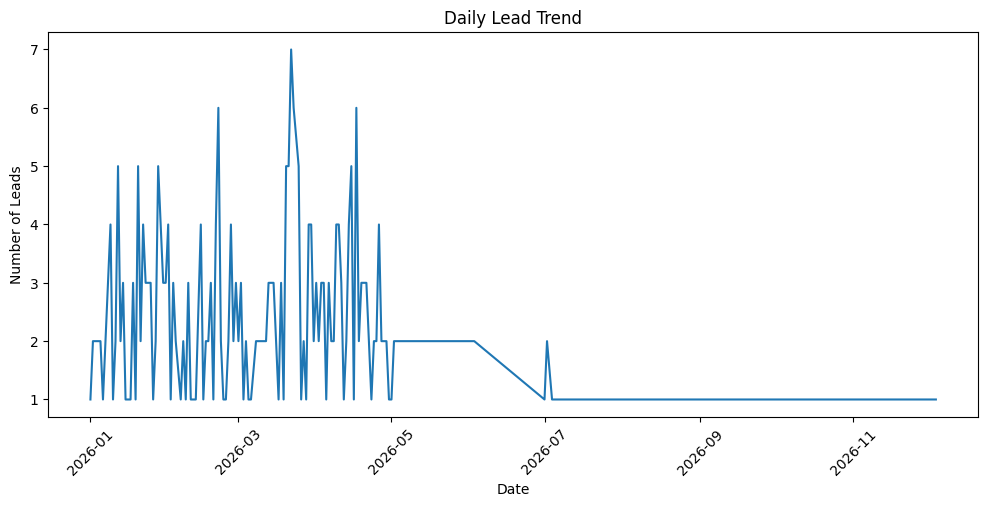

In [44]:
import matplotlib.pyplot as plt

daily_trend.plot(figsize=(12,5))

plt.title("Daily Lead Trend")

plt.xlabel("Date")

plt.ylabel("Number of Leads")

plt.xticks(rotation=45)

plt.show()

In [45]:
df['Week'] = df['Enquiry_Date'].dt.isocalendar().week

In [46]:
weekly_trend = df.groupby('Week')['Lead_ID'].count()

print(weekly_trend)

Week
1      5
2     13
3     15
4     21
5     22
6     10
7     11
8     20
9     15
10    10
11    10
12    24
13    19
14    18
15    19
16    23
17    17
18    10
23     4
27     4
31     2
32     2
36     2
40     1
45     1
49     2
Name: Lead_ID, dtype: int64


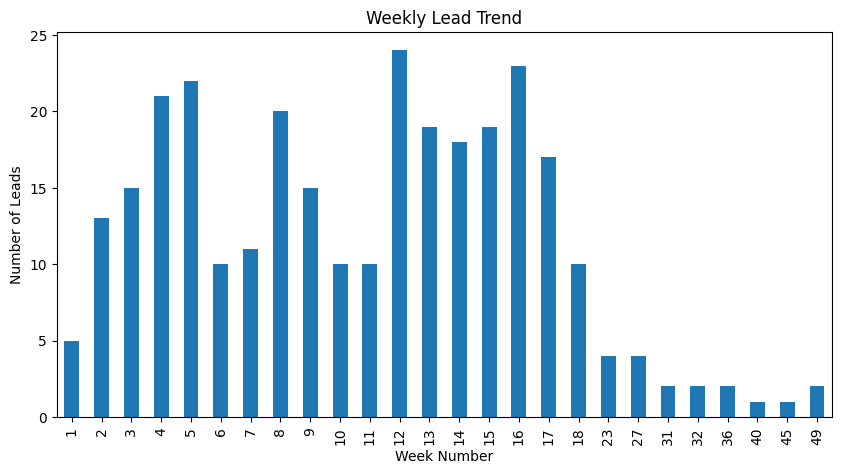

In [47]:
weekly_trend.plot(kind='bar', figsize=(10,5))

plt.title("Weekly Lead Trend")

plt.xlabel("Week Number")

plt.ylabel("Number of Leads")

plt.show()

In [48]:
df['Month'] = df['Enquiry_Date'].dt.month_name()

In [49]:
monthly_trend = df.groupby('Month')['Lead_ID'].count()

In [50]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_trend = monthly_trend.reindex(month_order)

In [51]:
print(monthly_trend)

Month
January      72
February     58
March        71
April        78
May           3
June          4
July          4
August        4
September     2
October       1
November      1
December      2
Name: Lead_ID, dtype: int64


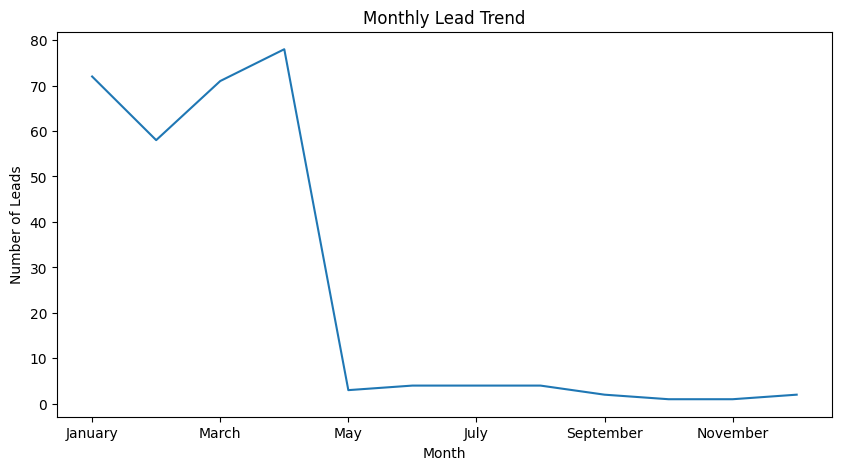

In [52]:
monthly_trend.plot(kind='line', figsize=(10,5))

plt.title("Monthly Lead Trend")

plt.xlabel("Month")

plt.ylabel("Number of Leads")

plt.show()

In [53]:
monthly_revenue = df.groupby('Month')['Revenue'].sum()

monthly_revenue = monthly_revenue.reindex(month_order)

print(monthly_revenue)

Month
January      655000
February     530000
March        795000
April        835000
May               0
June              0
July          40000
August        25000
September     35000
October           0
November      45000
December      30000
Name: Revenue, dtype: int64


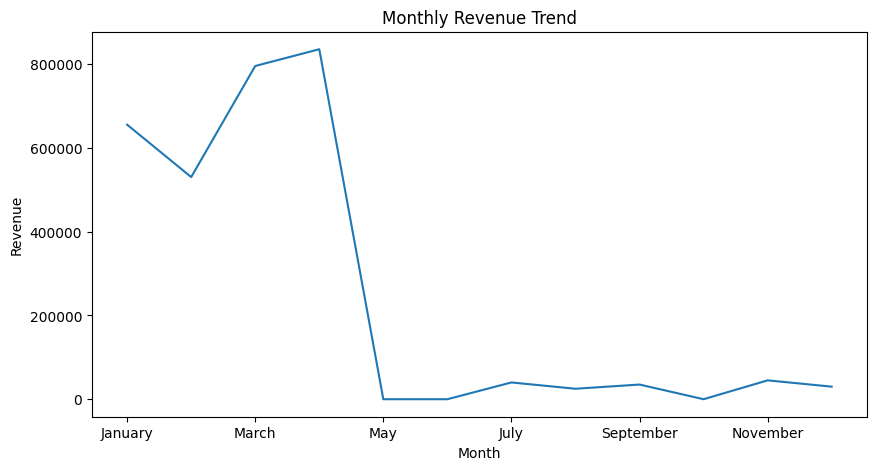

In [54]:
monthly_revenue.plot(kind='line', figsize=(10,5))

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [55]:
with pd.ExcelWriter("Trend_Analysis.xlsx") as writer:

    daily_trend.to_excel(writer, sheet_name='Daily_Trend')

    weekly_trend.to_excel(writer, sheet_name='Weekly_Trend')

    monthly_trend.to_excel(writer, sheet_name='Monthly_Trend')

    monthly_revenue.to_excel(writer, sheet_name='Revenue_Trend')